<a href="https://colab.research.google.com/github/SergioM02/Mineria_Datos/blob/exploracion-datos/Mineria_DatosEv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 1: Minería de Datos - Análisis Meteorológico en Australia

**Autor:** Sergio Martin

**Asignatura:** Minería de Datos

**Metodología utilizada:** CRISP-DM

---

## 1. Comprensión del Negocio (Contexto)
El presente proyecto tiene como objetivo analizar un conjunto de datos históricos sobre las condiciones climáticas en diversas estaciones meteorológicas de Australia. El propósito a largo plazo de este análisis es preparar los datos para entrenar un modelo de Machine Learning capaz de predecir si lloverá al día siguiente (clasificación) basándose en las condiciones climatológicas del día actual.

* **Fuente del Dataset:** [Rain in Australia - Kaggle](https://www.kaggle.com/code/mohamedzayton/rain-in-australia)
* **Descripción:** El dataset contiene aproximadamente 10 años de observaciones meteorológicas diarias obtenidas de numerosas ubicaciones en toda Australia.

---

## 2. Comprensión de los Datos (Mapeo Inicial)
A continuación, se presenta el mapeo conceptual de las variables presentes en el conjunto de datos, indicando su naturaleza para guiar el proceso de limpieza y análisis posterior:

* **Date:** Fecha de la observación (Temporal).
* **Location:** Nombre de la ciudad o ubicación de la estación meteorológica (Categórica).
* **MinTemp / MaxTemp:** Temperatura mínima y máxima registrada en grados Celsius (Numérica).
* **Rainfall:** Cantidad de lluvia caída en el día, medida en milímetros (Numérica).
* **Evaporation:** Evaporación en 24 horas en milímetros (Numérica).
* **Sunshine:** Número de horas de sol brillante en el día (Numérica).
* **WindGustDir / WindGustSpeed:** Dirección y velocidad de la ráfaga de viento más fuerte (Categórica / Numérica).
* **WindDir9am / WindDir3pm:** Dirección del viento a las 9 am y a las 3 pm (Categórica).
* **WindSpeed9am / WindSpeed3pm:** Velocidad del viento a las 9 am y a las 3 pm (Numérica).
* **Humidity9am / Humidity3pm:** Porcentaje de humedad a las 9 am y a las 3 pm (Numérica).
* **Pressure9am / Pressure3pm:** Presión atmosférica en hpa a las 9 am y a las 3 pm (Numérica).
* **Cloud9am / Cloud3pm:** Fracción del cielo cubierta por nubes (en octas) a las 9 am y a las 3 pm (Numérica).
* **Temp9am / Temp3pm:** Temperatura en grados Celsius a las 9 am y a las 3 pm (Numérica).
* **RainToday:** Variable booleana que indica si llovió en el día actual (Categórica).
* **RainTomorrow:** Variable objetivo (Target). Indica si llovió al día siguiente (Categórica - Booleana).

# Importar librerías y cargar dataset CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Septimo semestre/Minería de Datos/weatherAUS.csv")

# **Mapeo de datos**
**Columnas de dataset Rain in Australia**:

| Columna         | Tipo de Dato | Valores No Nulos | Valores Nulos | Descripción                                              |
|:----------------|:-------------|:-----------------|:--------------|:---------------------------------------------------------|
| **Date**        | object       | 145460           | 0             | La fecha de la observación.                              |
| **Location**    | object       | 145460           | 0             | El nombre de la ubicación de la estación meteorológica. |
| **MinTemp**     | float64      | 143975           | 1485          | Temperatura mínima en 24 horas.                          |
| **MaxTemp**     | float64      | 144199           | 1261          | Temperatura máxima en 24 horas.                          |
| **Rainfall**    | float64      | 142199           | 3261          | La cantidad de lluvia registrada ese día (mm).           |
| **Evaporation** | float64      | 82670            | 62790         | La evaporación (mm) en las últimas 24 horas.             |
| **Sunshine**    | float64      | 75625            | 69435         | La cantidad de horas de sol brillante ese día.           |
| **WindGustDir** | object       | 135134           | 10328         | Dirección del vendaval más fuerte en las últimas 24 horas. |
| **WindGustSpeed**| float64      | 135197           | 10263         | Velocidad (km/h) del vendaval más fuerte.                |
| **WindDir9am**  | object       | 134894           | 10566         | Dirección del viento a las 9 am.                         |
| **WindDir3pm**  | object       | 141232           | 4228          | Dirección del viento a las 3 pm.                         |
| **WindSpeed9am**| float64      | 143693           | 1767          | Velocidad del viento (km/h) a las 9 am.                  |
| **WindSpeed3pm**| float64      | 142398           | 3062          | Velocidad del viento (km/h) a las 3 pm.                  |
| **Humidity9am** | float64      | 142806           | 2654          | Humedad relativa (%) a las 9 am.                         |
| **Humidity3pm** | float64      | 140953           | 4507          | Humedad relativa (%) a las 3 pm.                         |
| **Pressure9am** | float64      | 130395           | 15065         | Presión atmosférica (hpa) a las 9 am.                    |
| **Pressure3pm** | float64      | 130432           | 15028         | Presión atmosférica (hpa) a las 3 pm.                    |
| **Cloud9am**    | float64      | 89572            | 55888         | Proporción del cielo cubierto por nubes a las 9 am.      |
| **Cloud3pm**    | float64      | 86102            | 59358         | Proporción del cielo cubierto por nubes a las 3 pm.      |
| **Temp9am**     | float64      | 143693           | 1767          | Temperatura (Celsius) a las 9 am.                        |
| **Temp3pm**     | float64      | 141851           | 3609          | Temperatura (Celsius) a las 3 pm.                        |
| **RainToday**   | object       | 142199           | 3261          | Si hubo lluvia ese día ('Yes'/'No').                     |
| **RainTomorrow**| object       | 142193           | 3267          | Si lloverá al día siguiente ('Yes'/'No').                |

In [ ]:
# Cantidad de filas y columnas
df.shape

(145460, 23)

In [ ]:
# Visualizar primeras 5 filas
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
# Vsualizar últimas 5 filas
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [ ]:
# ver nombres de columnas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [ ]:
# Ver no-nulos y tipos para cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

# **1. Búsqueda y Tratamiento de Valores Nulos**

**Justificación:**
Antes de poder entrenar un modelo de Machine Learning, es fundamental contar con un conjunto de datos íntegro. En esta etapa, primero calcularemos el porcentaje de valores nulos por cada variable. Aquellas columnas que superen un umbral crítico de datos faltantes (establecido en un 40%) serán eliminadas del dataset, ya que imputar una cantidad tan grande de datos introduciría un sesgo significativo.

Para las columnas restantes que aún presenten valores nulos, aplicaremos técnicas de imputación:
* **Variables Numéricas:** Se imputarán utilizando la *mediana*, ya que esta medida de tendencia central no se ve afectada por los valores atípicos (outliers) que trataremos en la siguiente etapa.
* **Variables Categóricas:** Se imputarán utilizando la *moda* (el valor más frecuente), manteniendo así la consistencia de las clases.

In [ ]:
# Contar cantidad de nulos por columna
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [ ]:
# 1. Calcular el porcentaje de nulos por columna
porcentaje_nulos = df.isnull().mean() * 100
print("Top 10 columnas con más nulos (%):\n")
print(porcentaje_nulos.sort_values(ascending=False).head(10))

# 2. Definir umbral y eliminar columnas con exceso de nulos
umbral = 40.0
columnas_a_eliminar = porcentaje_nulos[porcentaje_nulos > umbral].index
df = df.drop(columns=columnas_a_eliminar)
print(f"\nSe han eliminado las siguientes columnas por superar el {umbral}% de nulos:")
print(list(columnas_a_eliminar))

# 3. Imputar nulos en variables numéricas restantes (usando la Mediana)
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# 4. Imputar nulos en variables categóricas restantes (usando la Moda)
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 5. Verificar que el dataset quedó completamente limpio de nulos
nulos_restantes = df.isnull().sum().sum()
print(f"\nTotal de valores nulos restantes en el dataset: {nulos_restantes}")

Top 10 columnas con más nulos (%):

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
dtype: float64

Se han eliminado las siguientes columnas por superar el 40.0% de nulos:
['Evaporation', 'Sunshine', 'Cloud3pm']


/tmp/ipykernel_3439/4188836312.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3439/4188836312.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 


Total de valores nulos restantes en el dataset: 0


**Interpretación de los resultados:**

Al ejecutar el cálculo inicial, comprobé lo que sospechaba en la exploración previa: columnas como `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` tenían cerca o más del 40% de sus datos vacíos. Tomé la decisión de eliminar las primeras 3 por completo, dejando la columna `Cloud9am`; intentar rellenar casi la mitad de una columna basándome en suposiciones alteraría la realidad de las mediciones meteorológicas y perjudicaría nuestro futuro modelo de clasificación.

Para el resto de las columnas que sí conservamos, logré rellenar los espacios vacíos de manera segura. En el caso de los números (como temperaturas o milímetros de lluvia), utilicé la mediana para evitar que temperaturas extremas me distorsionaran el promedio. En los textos (como la dirección del viento), simplemente asigne el valor que más se repite en el historial. La verificación final me confirma que ahora el conjunto de datos tiene 0 valores nulos y está listo para ser procesado.

# **2. Detección y Tratamiento de Outliers (Valores Atípicos)**

**Justificación:**
Los algoritmos de Machine Learning son altamente sensibles a los valores atípicos, ya que estos pueden sesgar significativamente las métricas de error y la distribución de los datos durante el modelado. En esta fase, nos enfocaremos exclusivamente en las variables de naturaleza analítica cuantitativa (numéricas).

1. **Detección:** Utilizaremos gráficos de cajas (`Boxplots`) de la librería Seaborn para visualizar la distribución espacial de los datos y evidenciar los puntos que caen fuera de los "bigotes" del gráfico.
2. **Tratamiento:** Aplicaremos el método estadístico del **Rango Intercuartílico (IQR)**. En lugar de eliminar los registros anómalos (lo que reduciría el tamaño de nuestra muestra y perjudicaría el poder predictivo del futuro modelo), utilizaremos la técnica de *Capping* mediante `numpy.clip`. Esto ajustará los valores extremos llevándolos al límite superior o inferior aceptable, preservando la cantidad de filas de nuestro conjunto de datos y asegurando su admisibilidad volumétrica. No se requiere citar código externo, ya que esta es una aplicación matemática estándar utilizando funciones nativas de `pandas` y `numpy`.

**Se recomienda ver resultados en pantalla completa**

Distribución de variables numéricas antes del tratamiento (Outliers visibles):


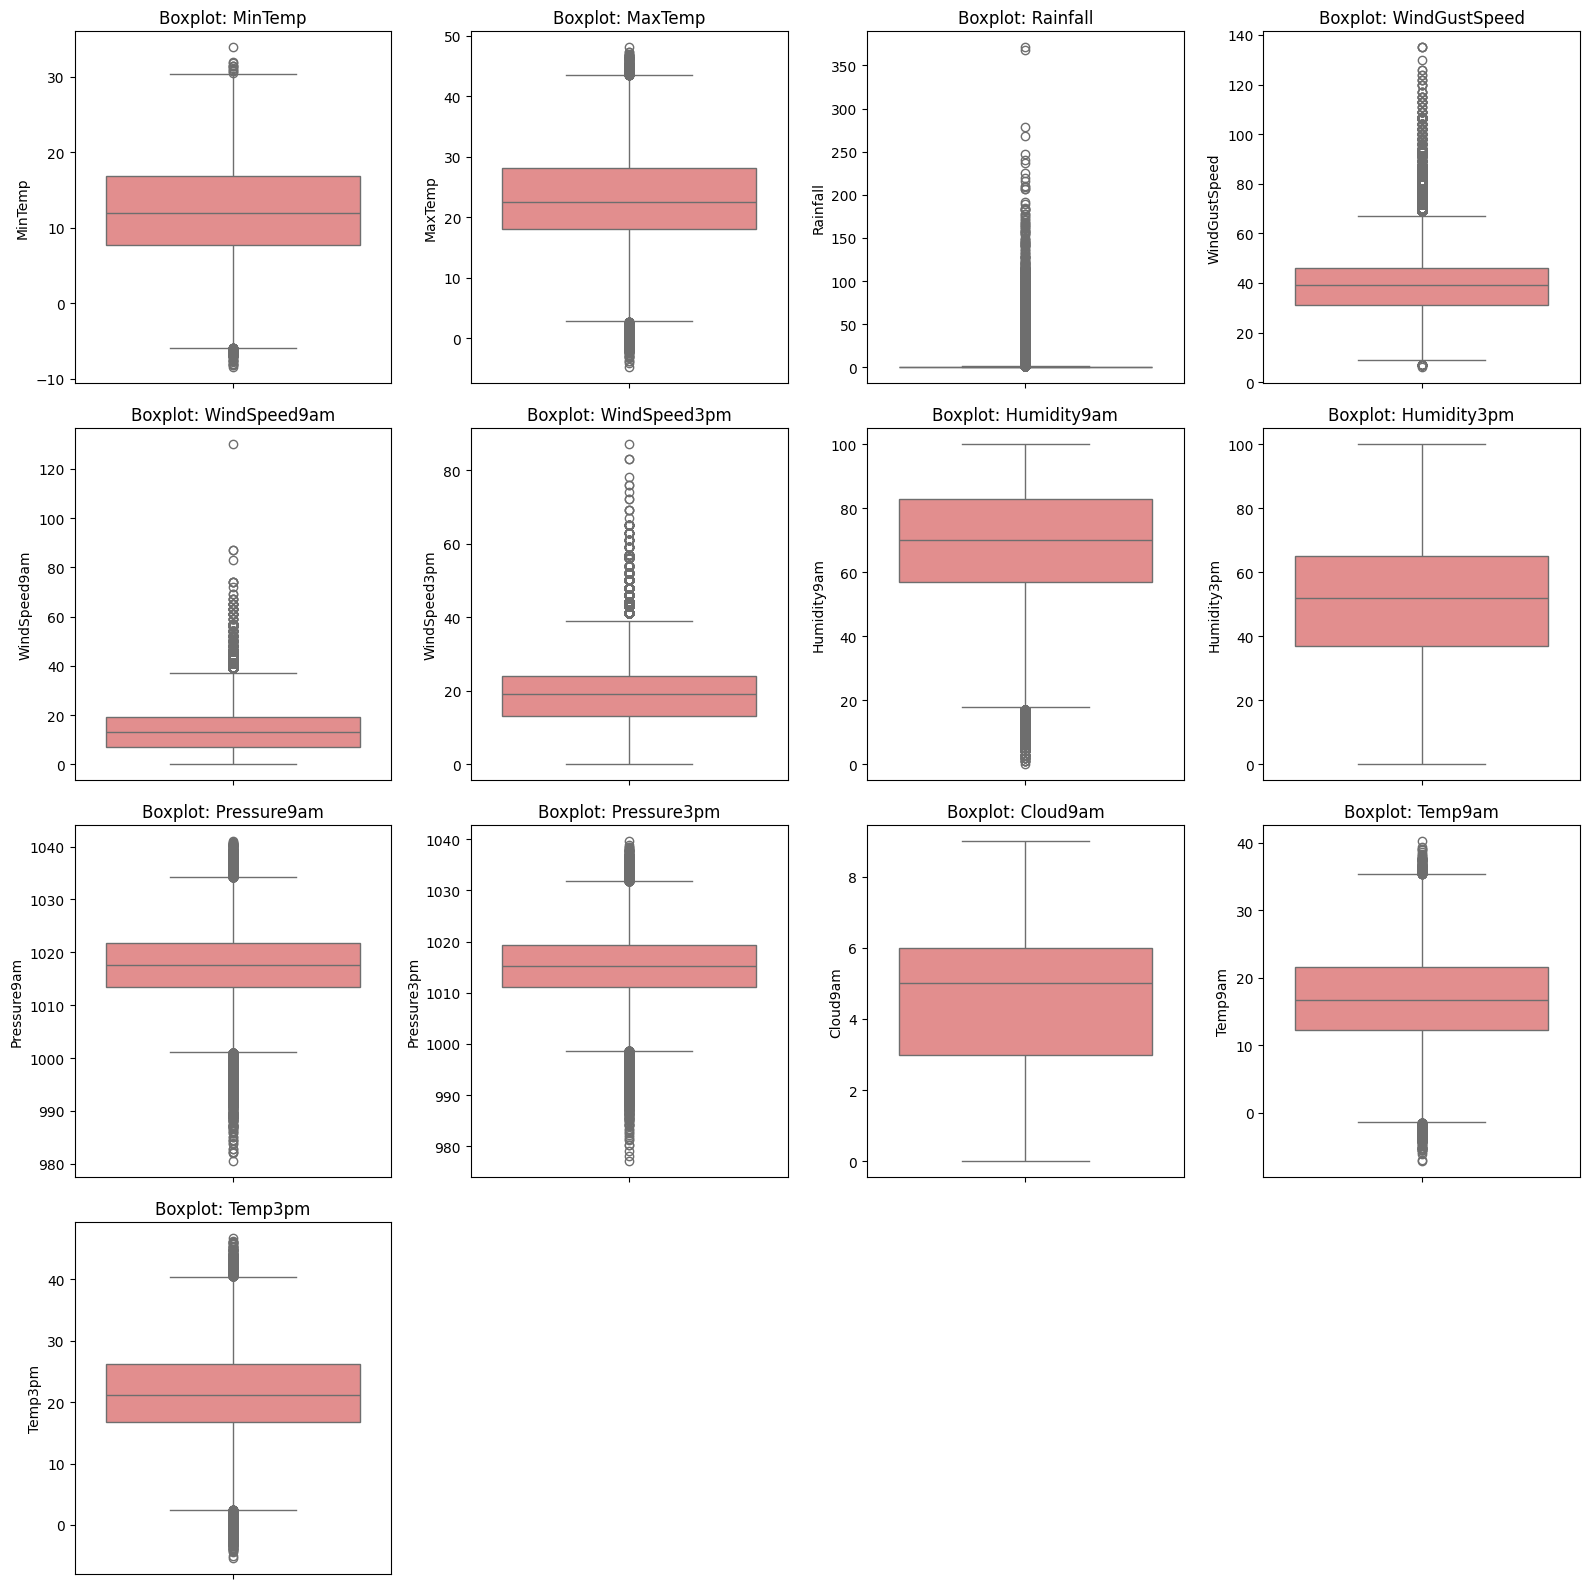


Distribución de variables numéricas después del tratamiento (Outliers mitigados):


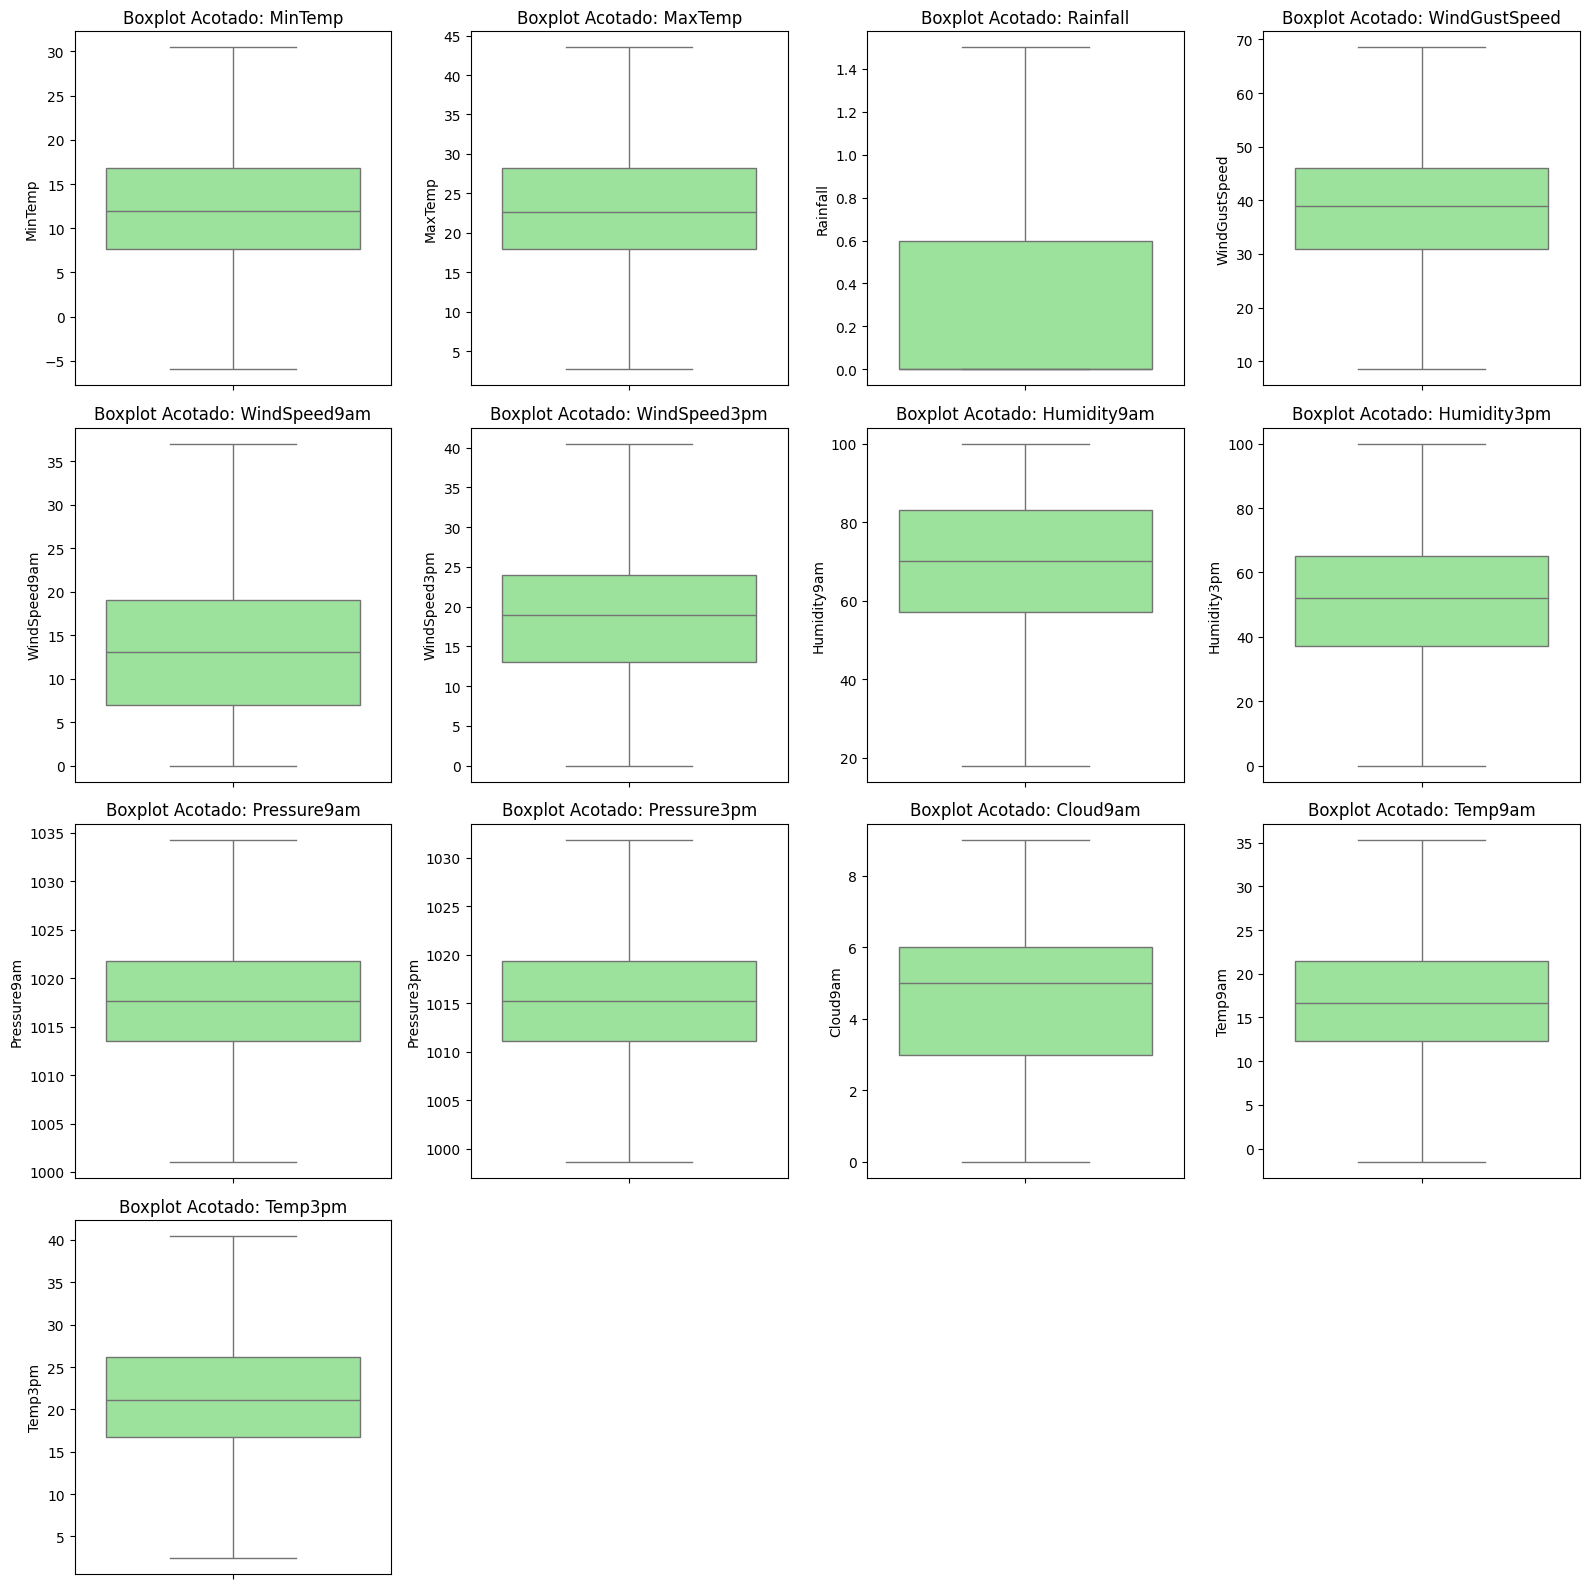

In [ ]:
# 1. Identificar variables numéricas (tipos informáticos float64 e int64)
cols_num = df.select_dtypes(include=['float64', 'int64']).columns

# Calculamos dinámicamente las dimensiones de la figura para los Boxplots
num_cols = len(cols_num)
filas = (num_cols // 4) + 1

# 2. Visualización antes del tratamiento
print("Distribución de variables numéricas antes del tratamiento (Outliers visibles):")
plt.figure(figsize=(16, 4 * filas))
for i, col in enumerate(cols_num, 1):
    plt.subplot(filas, 4, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# 3. Tratamiento de Outliers usando el método IQR (Capping/Winsorization)
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Aplicar el recorte (capping)
    df[col] = np.clip(df[col], limite_inferior, limite_superior)

# 4. Visualización después del tratamiento
print("\nDistribución de variables numéricas después del tratamiento (Outliers mitigados):")
plt.figure(figsize=(16, 4 * filas))
for i, col in enumerate(cols_num, 1):
    plt.subplot(filas, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot Acotado: {col}')
plt.tight_layout()
plt.show()

**Interpretación de los resultados:**

Al ejecutar este bloque, fue necesario contrastar el tipo de dato conceptual con su lectura técnica para poder aplicar el código estadístico. El análisis filtró correctamente solo las variables que representan magnitudes y cantidades (analíticamente numéricas), las cuales informáticamente el lenguaje Python interpreta y clasifica bajo los tipos `float64` (decimales, como la cantidad de lluvia en mm) e `int64` (enteros).

En la primera cuadrícula de gráficos (color rojo), observé una gran cantidad de puntos ubicados más allá de las líneas límite de los gráficos de caja. Estos representan valores meteorológicos extremos (por ejemplo, días con ráfagas de viento inusualmente fuertes o lluvias torrenciales atípicas). Si dejábamos estos valores intactos, nuestro futuro modelo intentaría aprender de estos "casos raros", empeorando su capacidad para predecir días normales.

Tras aplicar la fórmula del Rango Intercuartílico, la segunda cuadrícula de gráficos (color verde) muestra que los valores extremos han sido absorbidos hacia los límites normales de cada variable. Es decir, el día con la ráfaga de viento más extrema ahora registra el valor máximo considerado "normal" por la estadística. Con esto, logramos limpiar la distribución numérica sin borrar una sola fila, asegurando que el dataset mantenga su estatus de "amplio"  y robusto para la siguiente evaluación.

# **3. Transformación (Preprocesamiento)**

**Justificación:**
Los algoritmos de Machine Learning requieren que la totalidad de las entradas sean valores matemáticos. Por ende, debemos estandarizar nuestro conjunto de datos mediante dos procesos clave de transformación:

1. **Encoding (Codificación):** Las variables que conceptualmente son categóricas (como la ciudad de origen o la dirección del viento) informáticamente están registradas bajo el tipo de dato `object` (cadenas de texto). Utilizaremos la clase `LabelEncoder` de `scikit-learn` para traducir estas etiquetas de texto a valores numéricos enteros.
2. **Escalado (Estandarización):** Las variables conceptualmente cuantitativas (como la presión atmosférica o la humedad) se miden en unidades muy distintas, lo que genera magnitudes informáticas (`float64`) desproporcionadas entre sí. Si las dejamos así, el futuro modelo podría darle más peso erróneamente a las variables con números más grandes. Usaremos `StandardScaler` (Z-score normalization) para centrar estos datos continuos alrededor de una media de 0 y una desviación estándar de 1, equilibrando todo el conjunto y garantizando su robustez.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Tipos de datos informáticos ANTES de la transformación:\n", df.dtypes.value_counts())

# 1. ENCODING: Transformar variables categóricas (object) a numéricas
columnas_categoricas = df.select_dtypes(include=['object']).columns
encoder = LabelEncoder()

for col in columnas_categoricas:
    # Convertimos a string primero por seguridad, y luego aplicamos la transformación
    df[col] = encoder.fit_transform(df[col].astype(str))

# 2. ESCALADO: Estandarizar variables numéricas continuas (float64)
# Seleccionamos las continuas originales, evitando escalar las categóricas recién codificadas (que ahora son int)
columnas_numericas = df.select_dtypes(include=['float64']).columns
scaler = StandardScaler()

df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

print("\nTipos de datos informáticos DESPUÉS de la transformación:\n", df.dtypes.value_counts())
print("\nVista previa de los datos transformados (primeras 5 filas):")
display(df.head())

Tipos de datos informáticos ANTES de la transformación:
 float64    13
object      7
Name: count, dtype: int64

Tipos de datos informáticos DESPUÉS de la transformación:
 float64    13
int64       7
Name: count, dtype: int64

Vista previa de los datos transformados (primeras 5 filas):


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Temp9am,Temp3pm,RainToday,RainTomorrow
0,396,2,0.189751,-0.045242,0.358714,13,0.357816,13,14,0.708308,0.641629,0.109440,-1.443652,-1.518122,-1.251138,1.464068,-0.013695,0.018905,0,0
1,397,2,-0.752982,0.266030,-0.627098,14,0.357816,6,15,-1.161737,0.404729,-1.334095,-1.297105,-1.076618,-1.143922,0.149133,0.032883,0.385833,0,0
2,398,2,0.111190,0.350922,-0.627098,15,0.522075,13,15,0.591430,0.878529,-1.654880,-1.052860,-1.533347,-1.006073,0.149133,0.622866,0.224385,0,0
3,399,2,-0.470162,0.676343,-0.627098,4,-1.284777,9,0,-0.343592,-1.135122,-1.280631,-1.736746,-0.010917,-0.378095,0.149133,0.172616,0.708730,0,0
4,400,2,0.833951,1.284738,1.015921,13,0.111427,1,7,-0.811103,0.167829,0.697547,-0.906314,-1.046169,-1.419620,1.025756,0.126038,1.178398,0,0


**Interpretación de los resultados:**

A través de la consola de ejecución, puedo evidenciar directamente el contraste entre la naturaleza de los datos y su representación informática. Antes de ejecutar el código, el sistema detectaba múltiples columnas de tipo `object` (las variables conceptualmente categóricas). Al aplicar el *Encoding*, obligué al lenguaje a asignar un número identificador a cada categoría (por ejemplo, transformar "Yes" en 1 y "No" en 0); informáticamente, estas columnas pasaron a ser números enteros (`int32` o `int64`).

Al mismo tiempo, tomé las variables cuantitativas (las de tipo informático `float64`) y les apliqué el *Escalado*. Al mirar la tabla resultante, noto que valores como las temperaturas ya no aparecen en "grados Celsius", sino en valores decimales positivos y negativos cercanos al cero. Esto significa que la estandarización fue exitosa: las distancias entre los números se han normalizado.

Logramos convertir el 100% del DataFrame en una matriz matemática pura, sin eliminar ni una sola fila del dataset amplio original, asegurando de forma contundente la admisibilidad de estos datos para entrenar el futuro modelo predictivo de clasificación.

# **4. Análisis de Correlación (Matriz y Mapa de Calor)**

**Justificación:**
Para finalizar la etapa de comprensión y preparación de datos (según la metodología CRISP-DM), necesitamos entender cómo interactúan las variables entre sí. Aplicaremos el **coeficiente de correlación de Pearson**, el cual evalúa la relación lineal entre dos variables continuas, entregando un valor entre -1 (correlación negativa perfecta) y 1 (correlación positiva perfecta).

Esto tiene un doble propósito para nuestro futuro modelo de clasificación:
1. **Identificar predictores fuertes:** Ver qué variables tienen mayor influencia sobre nuestra probable variable objetivo (por ejemplo, si lloverá mañana).
2. **Detectar multicolinealidad:** Identificar si hay variables independientes que están demasiado correlacionadas entre sí (información redundante que podríamos necesitar filtrar a futuro).

*Nota sobre fuentes:* Para este paso, el código implementado utiliza las librerías `pandas` y `seaborn`, basándose en las buenas prácticas y material de apoyo alojado en el repositorio oficial del docente (`https://github.com/UXDynamicSolution/MineriaDatosDuocPAO`).

Tipos de datos listos para correlación:
 float64    13
int64       7
Name: count, dtype: int64


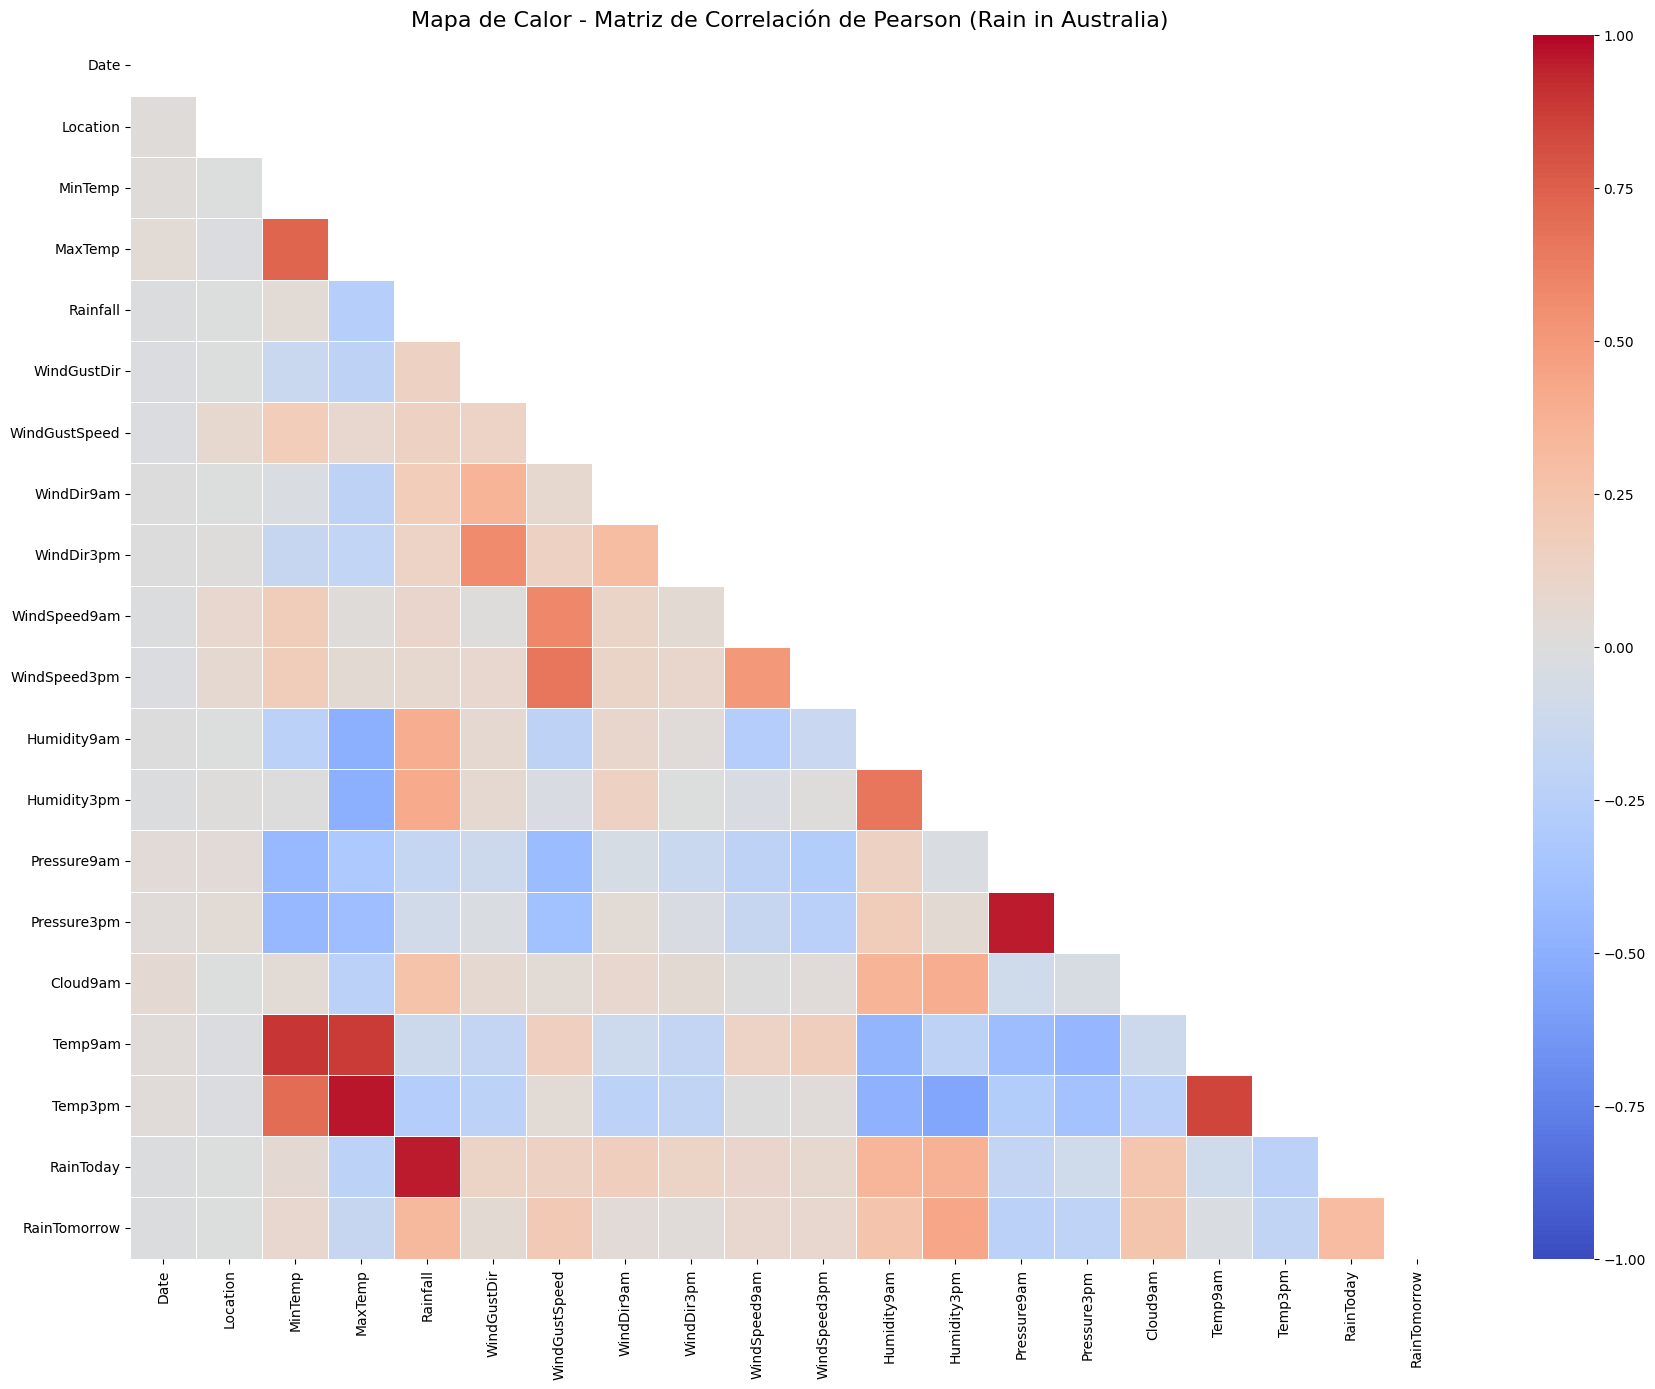


Top 5 correlaciones positivas más fuertes en el dataset:
MaxTemp      Temp3pm        0.968508
Pressure9am  Pressure3pm    0.959960
RainToday    Rainfall       0.956998
MinTemp      Temp9am        0.897917
Temp9am      MaxTemp        0.879546
dtype: float64


In [ ]:
# 1. Verificar que todas las columnas sean numéricas informáticamente (int o float)
# Esto es vital, ya que Pearson requiere datos matemáticos
print("Tipos de datos listos para correlación:\n", df.dtypes.value_counts())

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df.corr(method='pearson')

# 3. Visualizar mediante un Mapa de Calor (Heatmap)
# Configuramos un lienzo grande debido a la amplitud del dataset
plt.figure(figsize=(18, 14))

# Creamos una máscara para ocultar el triángulo superior (evita información duplicada/espejo)
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Dibujamos el Heatmap
sns.heatmap(matriz_correlacion,
            mask=mask,
            annot=False,        # Ocultamos los números exactos para no saturar visualmente el gráfico amplio
            cmap='coolwarm',    # Rojo para positiva, Azul para negativa
            vmin=-1, vmax=1,
            center=0,
            linewidths=0.5)

plt.title('Mapa de Calor - Matriz de Correlación de Pearson (Rain in Australia)', fontsize=16)
plt.tight_layout()
plt.show()

# Extra: Mostrar el top 5 de correlaciones más fuertes (positivas o negativas) excluyendo la diagonal
correlaciones_unstacked = matriz_correlacion.unstack()
correlaciones_ordenadas = correlaciones_unstacked.sort_values(kind="quicksort", ascending=False)
correlaciones_fuertes = correlaciones_ordenadas[correlaciones_ordenadas != 1.0].drop_duplicates().head(5)

print("\nTop 5 correlaciones positivas más fuertes en el dataset:")
print(correlaciones_fuertes)

**Interpretación de los resultados:**

Al ejecutar esta celda, compruebo la importancia del preprocesamiento realizado en el paso 3. Debido a que previamente transformamos todos los datos de tipo `object` (textos) a enteros (`int32`/`int64`) y escalamos las métricas (`float64`), la función `.corr()` de Pandas pudo procesar el 100% de las columnas sin arrojar errores, demostrando que nuestro dataset ahora es puramente analítico y matemático.

En el **Mapa de Calor**, los colores oscuros nos revelan información interesante. Por ejemplo, se observan tonos rojos intensos (correlación cercana a 1) entre variables lógicas de temperatura (como `Temp9am` y `MinTemp` o `MaxTemp`), lo que indica que a medida que una sube, la otra también. Por otro lado, los tonos azules intensos (correlación negativa) muestran relaciones inversas, como la humedad frente a la temperatura (a mayor temperatura, menor humedad relativa).

**Conclusión de Admisibilidad:** Con este último análisis, reafirmo que este conjunto de datos es altamente **admisible** y apropiado para la siguiente etapa de la asignatura. Tenemos un dataset *amplio* (con gran cantidad de registros sin nulos), *robusto* (sin outliers extremos que sesguen la varianza), con *variables mixtas* (categóricas codificadas y numéricas escaladas), y hemos evidenciado matemáticamente que existen correlaciones reales de las cuales un futuro modelo de Machine Learning podrá aprender patrones para clasificar si lloverá o no.